In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

sns.set_style("whitegrid")

In [23]:
df = pd.read_csv("HomeC.csv")

df.head()

C:\Users\Admin\AppData\Local\Temp\ipykernel_11568\2684743922.py:1: DtypeWarning: Columns (0: time, 1: cloudCover) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("HomeC.csv")


,time,use [kW],gen [kW],House overall [kW],Dishwasher [kW],Furnace 1 [kW],Furnace 2 [kW],Home office [kW],Fridge [kW],Wine cellar [kW],...,visibility,summary,apparentTemperature,pressure,windSpeed,cloudCover,windBearing,precipIntensity,dewPoint,precipProbability
0,1451624400,0.932833,0.003483,0.932833,0.000033,0.020700,0.061917,0.442633,0.124150,0.006983,...,10.0,Clear,29.26,1016.91,9.18,cloudCover,282.0,0.0,24.4,0.0
1,1451624401,0.934333,0.003467,0.934333,0.000000,0.020717,0.063817,0.444067,0.124000,0.006983,...,10.0,Clear,29.26,1016.91,9.18,cloudCover,282.0,0.0,24.4,0.0
2,1451624402,0.931817,0.003467,0.931817,0.000017,0.020700,0.062317,0.446067,0.123533,0.006983,...,10.0,Clear,29.26,1016.91,9.18,cloudCover,282.0,0.0,24.4,0.0
3,1451624403,1.022050,0.003483,1.022050,0.000017,0.106900,0.068517,0.446583,0.123133,0.006983,...,10.0,Clear,29.26,1016.91,9.18,cloudCover,282.0,0.0,24.4,0.0
4,1451624404,1.139400,0.003467,1.139400,0.000133,0.236933,0.063983,0.446533,0.122850,0.006850,...,10.0,Clear,29.26,1016.91,9.18,cloudCover,282.0,0.0,24.4,0.0


In [19]:
numeric_cols = df.select_dtypes(include=['float64','int64']).columns

print("Numeric columns:", numeric_cols)

Numeric columns: Index(['use [kW]', 'gen [kW]', 'House overall [kW]', 'Dishwasher [kW]',
       'Furnace 1 [kW]', 'Furnace 2 [kW]', 'Home office [kW]', 'Fridge [kW]',
       'Wine cellar [kW]', 'Garage door [kW]', 'Kitchen 12 [kW]',
       'Kitchen 14 [kW]', 'Kitchen 38 [kW]', 'Barn [kW]', 'Well [kW]',
       'Microwave [kW]', 'Living room [kW]', 'Solar [kW]', 'temperature',
       'humidity', 'visibility', 'apparentTemperature', 'pressure',
       'windSpeed', 'windBearing', 'precipIntensity', 'dewPoint',
       'precipProbability'],
      dtype='str')


In [20]:
target_col = numeric_cols[0]

print("Using column:", target_col)

Using column: use [kW]


In [29]:
# convert time column to numeric first
df['time'] = pd.to_numeric(df['time'], errors='coerce')

# now convert unix timestamp to datetime
df['time'] = pd.to_datetime(df['time'], unit='s')

# sort and set index
df = df.sort_values('time')
df = df.set_index('time')

print("Time column converted successfully")
df.head()

Time column converted successfully


,use [kW],gen [kW],House overall [kW],Dishwasher [kW],Furnace 1 [kW],Furnace 2 [kW],Home office [kW],Fridge [kW],Wine cellar [kW],Garage door [kW],...,visibility,summary,apparentTemperature,pressure,windSpeed,cloudCover,windBearing,precipIntensity,dewPoint,precipProbability
time,,,,,,,,,,,,,,,,,,,,,
2016-01-01 05:00:00,0.932833,0.003483,0.932833,0.000033,0.020700,0.061917,0.442633,0.124150,0.006983,0.013083,...,10.0,Clear,29.26,1016.91,9.18,cloudCover,282.0,0.0,24.4,0.0
2016-01-01 05:00:01,0.934333,0.003467,0.934333,0.000000,0.020717,0.063817,0.444067,0.124000,0.006983,0.013117,...,10.0,Clear,29.26,1016.91,9.18,cloudCover,282.0,0.0,24.4,0.0
2016-01-01 05:00:02,0.931817,0.003467,0.931817,0.000017,0.020700,0.062317,0.446067,0.123533,0.006983,0.013083,...,10.0,Clear,29.26,1016.91,9.18,cloudCover,282.0,0.0,24.4,0.0
2016-01-01 05:00:03,1.022050,0.003483,1.022050,0.000017,0.106900,0.068517,0.446583,0.123133,0.006983,0.013000,...,10.0,Clear,29.26,1016.91,9.18,cloudCover,282.0,0.0,24.4,0.0
2016-01-01 05:00:04,1.139400,0.003467,1.139400,0.000133,0.236933,0.063983,0.446533,0.122850,0.006850,0.012783,...,10.0,Clear,29.26,1016.91,9.18,cloudCover,282.0,0.0,24.4,0.0


In [30]:
df = pd.read_csv("HomeC.csv", low_memory=False)

df['time'] = pd.to_numeric(df['time'], errors='coerce')

df['time'] = pd.to_datetime(df['time'], unit='s')

df = df.sort_values('time')

df = df.set_index('time')

df.head()

,use [kW],gen [kW],House overall [kW],Dishwasher [kW],Furnace 1 [kW],Furnace 2 [kW],Home office [kW],Fridge [kW],Wine cellar [kW],Garage door [kW],...,visibility,summary,apparentTemperature,pressure,windSpeed,cloudCover,windBearing,precipIntensity,dewPoint,precipProbability
time,,,,,,,,,,,,,,,,,,,,,
2016-01-01 05:00:00,0.932833,0.003483,0.932833,0.000033,0.020700,0.061917,0.442633,0.124150,0.006983,0.013083,...,10.0,Clear,29.26,1016.91,9.18,cloudCover,282.0,0.0,24.4,0.0
2016-01-01 05:00:01,0.934333,0.003467,0.934333,0.000000,0.020717,0.063817,0.444067,0.124000,0.006983,0.013117,...,10.0,Clear,29.26,1016.91,9.18,cloudCover,282.0,0.0,24.4,0.0
2016-01-01 05:00:02,0.931817,0.003467,0.931817,0.000017,0.020700,0.062317,0.446067,0.123533,0.006983,0.013083,...,10.0,Clear,29.26,1016.91,9.18,cloudCover,282.0,0.0,24.4,0.0
2016-01-01 05:00:03,1.022050,0.003483,1.022050,0.000017,0.106900,0.068517,0.446583,0.123133,0.006983,0.013000,...,10.0,Clear,29.26,1016.91,9.18,cloudCover,282.0,0.0,24.4,0.0
2016-01-01 05:00:04,1.139400,0.003467,1.139400,0.000133,0.236933,0.063983,0.446533,0.122850,0.006850,0.012783,...,10.0,Clear,29.26,1016.91,9.18,cloudCover,282.0,0.0,24.4,0.0


In [31]:
z_scores = np.abs(stats.zscore(df[target_col]))

threshold = 3

outliers = df[z_scores > threshold]

print("Number of outliers detected:", len(outliers))

Number of outliers detected: 0


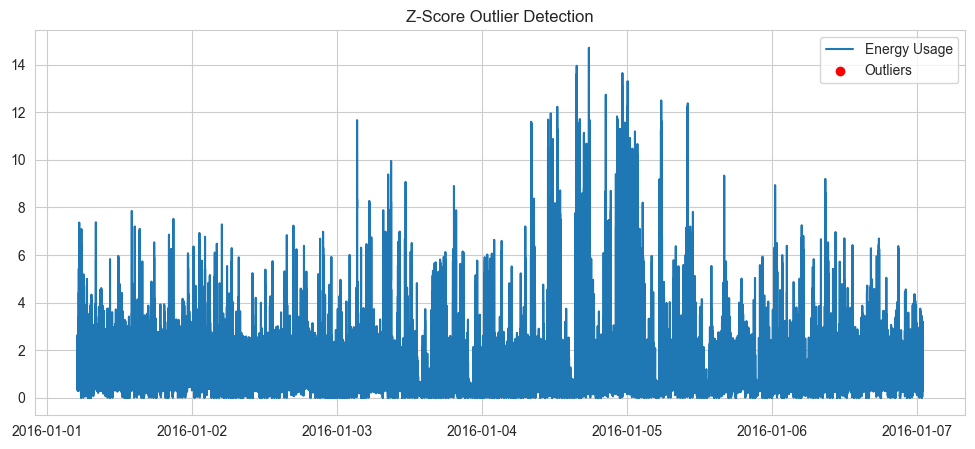

In [32]:
plt.figure(figsize=(12,5))

plt.plot(df.index, df[target_col], label="Energy Usage")

plt.scatter(outliers.index, outliers[target_col], color="red", label="Outliers")

plt.legend()

plt.title("Z-Score Outlier Detection")

plt.show()

In [34]:

df_clean = df[z_scores < threshold]

print("Original data shape:", df.shape)

print("Cleaned data shape:", df_clean.shape)

Original data shape: (503911, 31)
Cleaned data shape: (0, 31)


In [36]:
hourly_data = df_clean.resample("h").mean()

daily_data = df_clean.resample("d").mean()

print(hourly_data.head())

Empty DataFrame
Columns: [use [kW], gen [kW], House overall [kW], Dishwasher [kW], Furnace 1 [kW], Furnace 2 [kW], Home office [kW], Fridge [kW], Wine cellar [kW], Garage door [kW], Kitchen 12 [kW], Kitchen 14 [kW], Kitchen 38 [kW], Barn [kW], Well [kW], Microwave [kW], Living room [kW], Solar [kW], temperature, icon, humidity, visibility, summary, apparentTemperature, pressure, windSpeed, cloudCover, windBearing, precipIntensity, dewPoint, precipProbability]
Index: []

[0 rows x 31 columns]


C:\Users\Admin\AppData\Local\Temp\ipykernel_11568\3971377860.py:3: Pandas4Warning: 'd' is deprecated and will be removed in a future version, please use 'D' instead.
  daily_data = df_clean.resample("d").mean()


In [37]:
hourly_data["hour"] = hourly_data.index.hour
hourly_data["day"] = hourly_data.index.dayofweek
hourly_data["month"] = hourly_data.index.month

hourly_data.head()

,use [kW],gen [kW],House overall [kW],Dishwasher [kW],Furnace 1 [kW],Furnace 2 [kW],Home office [kW],Fridge [kW],Wine cellar [kW],Garage door [kW],...,pressure,windSpeed,cloudCover,windBearing,precipIntensity,dewPoint,precipProbability,hour,day,month
time,,,,,,,,,,,,,,,,,,,,,


In [42]:
# selected only numeric columns
numeric_df = df.select_dtypes(include=['float64','int64'])

# resample numeric data
hourly_data = numeric_df.resample("h").mean()

print(hourly_data.head())

                     use [kW]  gen [kW]  House overall [kW]  Dishwasher [kW]  \
time                                                                           
2016-01-01 05:00:00  1.187276  0.038035            1.187276         0.055087   
2016-01-01 06:00:00  1.119695  0.080241            1.119695         0.044929   
2016-01-01 07:00:00  0.953479  0.074560            0.953479         0.036512   
2016-01-01 08:00:00  1.080323  0.013110            1.080323         0.030701   
2016-01-01 09:00:00  1.064834  0.046615            1.064834         0.042406   

                     Furnace 1 [kW]  Furnace 2 [kW]  Home office [kW]  \
time                                                                    
2016-01-01 05:00:00        0.209051        0.236018          0.091815   
2016-01-01 06:00:00        0.237062        0.251944          0.131420   
2016-01-01 07:00:00        0.225252        0.204517          0.100471   
2016-01-01 08:00:00        0.157488        0.187387          0.097202   
2

In [43]:
hourly_data["hour"] = hourly_data.index.hour

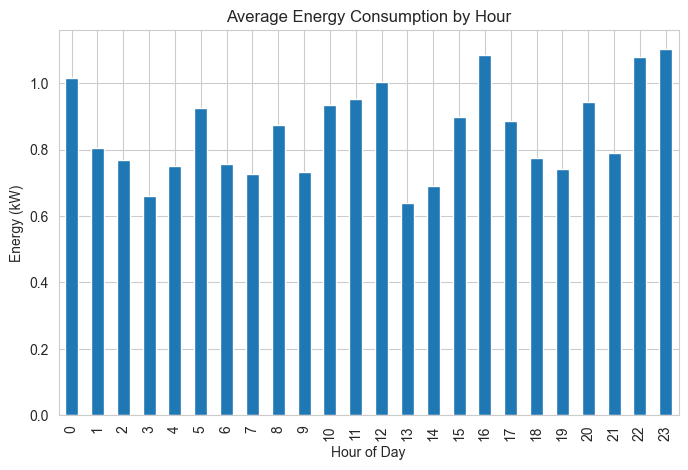

In [44]:
target_col = "use [kW]"

hourly_pattern = hourly_data.groupby("hour")[target_col].mean()

plt.figure(figsize=(8,5))

hourly_pattern.plot(kind="bar")

plt.title("Average Energy Consumption by Hour")

plt.xlabel("Hour of Day")

plt.ylabel("Energy (kW)")

plt.show()

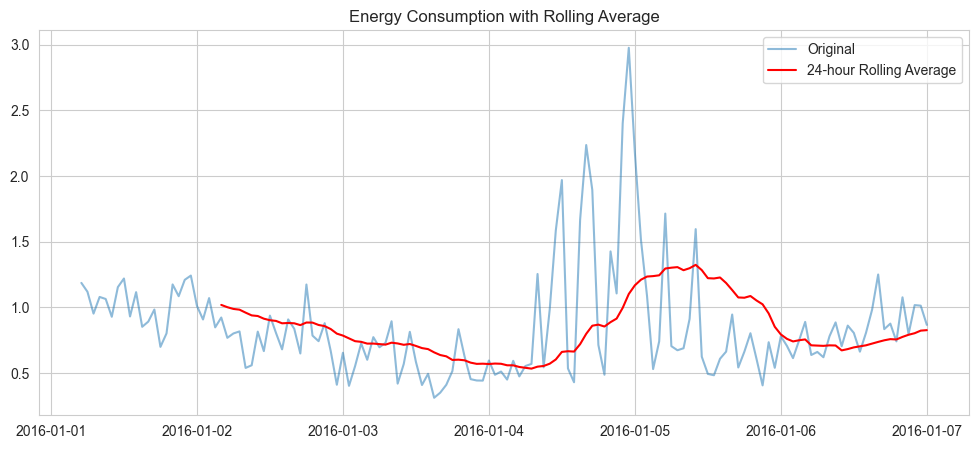

In [45]:
rolling_avg = hourly_data[target_col].rolling(window=24).mean()

plt.figure(figsize=(12,5))

plt.plot(hourly_data[target_col], alpha=0.5, label="Original")

plt.plot(rolling_avg, color="red", label="24-hour Rolling Average")

plt.legend()

plt.title("Energy Consumption with Rolling Average")

plt.show()